# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 3: Modelado del sistema de recomendación

En este notebook se desarrolla la etapa de modelado del sistema de recomendación a partir del dataset de Olist.

Se implementa un modelo baseline basado en popularidad y un modelo principal de factorización de matrices mediante ALS (Alternating Least Squares), en coherencia con la propuesta del proyecto.

Además, se incorpora una segmentación de usuarios con K-Means como apoyo analítico para enriquecer la interpretación de los resultados.

## Objetivo del notebook

El objetivo es construir, comparar y justificar distintos enfoques de recomendación para sugerir productos a los usuarios en base a su comportamiento histórico de compra.

Se busca:

- implementar un baseline de comparación;
- entrenar un modelo ALS para feedback implícito;
- evaluar el sistema mediante métricas apropiadas;
- complementar el análisis con segmentación de usuarios;
- justificar técnicamente la elección del modelo final.

## Enfoque metodológico

Dado que el dataset presenta:

- alta sparsity,
- interacciones implícitas (compras en lugar de ratings explícitos completos),
- y una gran cantidad de usuarios y productos,

se utilizará un enfoque de factorización de matrices mediante **TruncatedSVD**, que permite capturar factores latentes en la matriz usuario-producto.

Este enfoque resulta adecuado para trabajar con estructuras dispersas y permite aproximar relaciones entre usuarios y productos en un espacio reducido.

Como referencia inicial, se implementará primero un baseline basado en popularidad.

In [42]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [58]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [59]:
# Cargar dataset de traducción (si usás kagglehub)
translation = pd.read_csv(
    os.path.join(path, "product_category_name_translation.csv")
)

In [60]:
products = pd.read_csv(
    os.path.join(path, "olist_products_dataset.csv")
)

## Modelo 1: baseline basado en popularidad

Como punto de partida, se implementa un modelo baseline que recomienda los productos con mayor número de interacciones observadas en el dataset.

Este enfoque no personaliza las recomendaciones, pero resulta útil como referencia inicial para comparar el comportamiento de modelos más avanzados.

In [61]:
baseline_populares = (
    df_interactions["product_id"]
    .value_counts()
    .reset_index()
)

baseline_populares.columns = ["product_id", "frecuencia"]
baseline_populares.head(10)

,product_id,frecuencia
0,99a4788cb24856965c36a24e339b6058,466
1,aca2eb7d00ea1a7b8ebd4e68314663af,430
2,422879e10f46682990de24d770e7f83d,349
3,d1c427060a0f73f6b889a5c7c61f2ac4,322
4,389d119b48cf3043d311335e499d9c6b,310
5,53b36df67ebb7c41585e8d54d6772e08,303
6,368c6c730842d78016ad823897a372db,289
7,53759a2ecddad2bb87a079a1f1519f73,283
8,154e7e31ebfa092203795c972e5804a6,268
9,2b4609f8948be18874494203496bc318,257


In [62]:
productos_categorias = df[["product_id", "product_category_name"]].drop_duplicates()
productos_categorias["product_category_name"] = productos_categorias["product_category_name"].fillna("sin_categoria")

baseline_top10 = baseline_populares.head(10).merge(
    productos_categorias,
    on="product_id",
    how="left"
)

baseline_top10

,product_id,frecuencia,product_category_name
0,99a4788cb24856965c36a24e339b6058,466,cama_mesa_banho
1,aca2eb7d00ea1a7b8ebd4e68314663af,430,moveis_decoracao
2,422879e10f46682990de24d770e7f83d,349,ferramentas_jardim
3,d1c427060a0f73f6b889a5c7c61f2ac4,322,informatica_acessorios
4,389d119b48cf3043d311335e499d9c6b,310,ferramentas_jardim
5,53b36df67ebb7c41585e8d54d6772e08,303,relogios_presentes
6,368c6c730842d78016ad823897a372db,289,ferramentas_jardim
7,53759a2ecddad2bb87a079a1f1519f73,283,ferramentas_jardim
8,154e7e31ebfa092203795c972e5804a6,268,beleza_saude
9,2b4609f8948be18874494203496bc318,257,beleza_saude


### Interpretación del baseline

El modelo baseline identifica los productos más frecuentes en el conjunto de interacciones.

#### Ventajas
- simple implementación;
- bajo costo computacional;
- útil como punto de comparación.

#### Limitaciones
- no personaliza recomendaciones;
- favorece productos populares;
- no aborda el problema de long tail.

Por esta razón, se utiliza únicamente como referencia inicial.

_______________________________________________________________________________

## Ajuste metodológico por limitaciones computacionales

La construcción completa de la matriz usuario-producto presenta un costo computacional elevado debido a la cantidad de usuarios, productos y al nivel de sparsity del dataset.

Por este motivo, se trabaja con una muestra controlada compuesta por los usuarios y productos con mayor nivel de interacción.

Esta decisión permite:

- reducir el consumo de memoria;
- preservar la lógica del problema de recomendación;
- y demostrar el funcionamiento del modelo en un entorno representativo.

In [63]:
top_users = df_interactions["customer_unique_id"].value_counts().head(1000).index
top_products = df_interactions["product_id"].value_counts().head(500).index

df_sample = df_interactions[
    df_interactions["customer_unique_id"].isin(top_users) &
    df_interactions["product_id"].isin(top_products)
].copy()

print(df_sample.shape)
df_sample.head()

(451, 3)


,customer_unique_id,product_id,interaction
152,6204c4e582a95b6a350adf6988623bfb,fb7a100ec8c7b34f60cec22b1a9a10e0,1
248,8004f80e361a5ee23aadb7418a685fc2,ee0c1cf2fbeae95205b4aa506f1469f0,1
506,b1079e3544bf2cf3786e52f5f0220738,07c055536ebf10dfbb6c6db6dbfc36e5,1
509,d6caf670c8bf91aed723f242cafb71c8,422879e10f46682990de24d770e7f83d,1
526,aaff146bd210808c7d004a05966472a7,283dc451ad3918badb976d56ff887289,1


In [65]:
user_item_matrix = df_sample.pivot_table(
    index="customer_unique_id",
    columns="product_id",
    values="interaction",
    fill_value=0
)

print(user_item_matrix.shape)
user_item_matrix.head()

(322, 211)


product_id,0152f69b6cf919bcdaf117aa8c43e5a2,017692475c1c954ff597feda05131d73,027cdd14a677a5834bc67a9789db5021,060cb19345d90064d1015407193c233d,06edb72f1e0c64b14c5b79353f7abea3,07c055536ebf10dfbb6c6db6dbfc36e5,08574b074924071f4e201e151b152b4e,0a4093a4af429dc0a9334300e5c13ae5,0aabfb375647d9738ad0f7b4ea3653b1,0bbdc963004d9b2fd3427ee3c5ae3608,...,f6fa93875f4a7dac03e0a22143f4d815,f731f8587d4088c174397e010cf892a9,f7a17d2c51d9df89a4f1711c4ac17f33,f7f59e6186e10983a061ac7bdb3494d6,f819f0c84a64f02d3a5606ca95edd272,fb55982be901439613a95940feefd9ee,fb7a100ec8c7b34f60cec22b1a9a10e0,fbc1488c1a1e72ba175f53ab29a248e8,fbce4c4cb307679d89a3bf3d3bb353b9,fe9dfbe7f974621789683b7b78be2a16
customer_unique_id,,,,,,,,,,,,,,,,,,,,,
0178b244a5c281fb2ade54038dd4b161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01a22e2079ea71e17313b88e5811e54a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0241fa2e9adf0576cb0f845377d05c03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02b20b7c813efede140142ac610e36dc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02e9109b7e0a985108b43e573b6afb23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
sparsity_sample = 1.0 - (np.count_nonzero(user_item_matrix) / user_item_matrix.size)
print(f"Sparsity de la muestra: {sparsity_sample:.6f}")

Sparsity de la muestra: 0.993362


### Interpretación de la Sparsity de la muestra

La matriz usuario-producto presenta una sparsity del 99.33%, lo que indica que la gran mayoría de las combinaciones usuario–producto no poseen interacción.

Este comportamiento es consistente con datasets reales de e-commerce, donde los usuarios interactúan con un número muy limitado de productos en relación al catálogo total.

#### Implicancias para el modelado:

- Los métodos simples como popularidad o similitud directa tienen capacidad limitada para generalizar.
- El filtrado colaborativo basado en vecinos (user-user o item-item) pierde efectividad en escenarios altamente dispersos.
- Se requiere un modelo capaz de capturar relaciones latentes entre usuarios y productos.

#### Decisión técnica:

Se selecciona un enfoque basado en reducción de dimensionalidad (Truncated SVD), que permite:

- manejar matrices dispersas de gran tamaño;
- inferir preferencias implícitas;
- mejorar la calidad de las recomendaciones en contextos con baja densidad de datos.

In [67]:
from sklearn.decomposition import TruncatedSVD

# Definimos el modelo
svd = TruncatedSVD(n_components=20, random_state=42)

# Entrenamos sobre la matriz
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_

print("Modelo SVD entrenado")

Modelo SVD entrenado


In [68]:
# Reconstrucción de la matriz (predicciones)
pred_matrix = np.dot(user_factors, item_factors)

# Convertimos a DataFrame para trabajar mejor
pred_df = pd.DataFrame(
    pred_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

pred_df.head()

product_id,0152f69b6cf919bcdaf117aa8c43e5a2,017692475c1c954ff597feda05131d73,027cdd14a677a5834bc67a9789db5021,060cb19345d90064d1015407193c233d,06edb72f1e0c64b14c5b79353f7abea3,07c055536ebf10dfbb6c6db6dbfc36e5,08574b074924071f4e201e151b152b4e,0a4093a4af429dc0a9334300e5c13ae5,0aabfb375647d9738ad0f7b4ea3653b1,0bbdc963004d9b2fd3427ee3c5ae3608,...,f6fa93875f4a7dac03e0a22143f4d815,f731f8587d4088c174397e010cf892a9,f7a17d2c51d9df89a4f1711c4ac17f33,f7f59e6186e10983a061ac7bdb3494d6,f819f0c84a64f02d3a5606ca95edd272,fb55982be901439613a95940feefd9ee,fb7a100ec8c7b34f60cec22b1a9a10e0,fbc1488c1a1e72ba175f53ab29a248e8,fbce4c4cb307679d89a3bf3d3bb353b9,fe9dfbe7f974621789683b7b78be2a16
customer_unique_id,,,,,,,,,,,,,,,,,,,,,
0178b244a5c281fb2ade54038dd4b161,-1.722630e-03,1.372039e-06,1.420276e-06,-0.008116,0.040106,-0.002785,4.120415e-05,-6.148902e-03,3.596806e-04,-4.331527e-03,...,-2.429848e-06,6.377223e-04,-1.456958e-06,2.319724e-06,-1.699007e-04,1.019981e-04,5.266581e-07,4.989785e-03,1.745690e-05,2.916580e-07
01a22e2079ea71e17313b88e5811e54a,1.343985e-02,1.967532e-05,-1.210700e-05,-0.000629,-0.001785,-0.001701,1.979292e-04,2.026606e-02,-8.776025e-04,-7.274004e-04,...,1.330640e-05,4.751533e-03,-2.696067e-05,-1.924210e-05,-1.584838e-03,1.330557e-03,1.232645e-05,1.076946e-02,6.358322e-05,-5.523015e-06
0241fa2e9adf0576cb0f845377d05c03,-1.180155e-04,1.506664e-07,-2.199587e-07,0.000856,0.000127,0.000175,3.316552e-05,-1.586206e-04,-4.634477e-05,3.984036e-06,...,5.017341e-07,1.400874e-04,-2.895201e-07,7.695101e-08,-1.124907e-05,-9.982701e-06,-5.178387e-07,1.597420e-03,2.468182e-05,3.086076e-07
02b20b7c813efede140142ac610e36dc,4.609035e-03,8.326659e-06,1.555096e-05,0.001012,0.001112,-0.000056,-2.014088e-04,2.929026e-03,-1.242981e-04,4.934368e-04,...,-9.090281e-07,8.505831e-04,-5.575527e-06,9.726921e-06,-1.691396e-04,7.644944e-04,-6.550177e-06,9.012914e-03,2.420644e-04,-3.359006e-06
02e9109b7e0a985108b43e573b6afb23,-8.713379e-08,-1.232282e-09,2.299397e-10,-0.000005,-0.000003,-0.000010,-6.030643e-08,-9.360042e-07,1.765517e-07,-4.763710e-07,...,-2.585130e-09,-1.259603e-07,2.319102e-10,8.913110e-10,-1.386833e-08,4.089300e-08,6.756488e-10,-8.618678e-07,-2.114629e-08,-8.641718e-10


In [73]:
def recomendar_svd(user_id, top_n=5):
    
    if user_id not in pred_df.index:
        return "Usuario no encontrado"
    
    # productos ya comprados
    productos_comprados = user_item_matrix.loc[user_id]
    productos_comprados = productos_comprados[productos_comprados > 0].index.tolist()
    
    # predicciones del modelo
    scores = pred_df.loc[user_id]
    
    # sacamos los ya comprados
    scores = scores.drop(labels=productos_comprados, errors="ignore")
    
    # ordenamos
    recomendaciones = scores.sort_values(ascending=False).head(top_n)
    
    return recomendaciones

In [74]:
usuario = user_item_matrix.index[0]
recomendar_svd(usuario)

product_id
f2e53dd1670f3c376518263b3f71424d    0.235357
3e5201fe0d1ba474d9b90152c83c706c    0.123295
5a848e4ab52fd5445cdc07aab1c40e48    0.069473
35afc973633aaeb6b877ff57b2793310    0.047903
06edb72f1e0c64b14c5b79353f7abea3    0.040106
Name: 0178b244a5c281fb2ade54038dd4b161, dtype: float64

In [75]:
# Armamos tabla de productos con categoría
productos_categorias = products.merge(
    translation,
    on="product_category_name",
    how="left"
)[["product_id", "product_category_name_english"]]

In [78]:
def recomendar_svd_detallado(user_id, top_n=5):
    
    if user_id not in pred_df.index:
        return "Usuario no encontrado"
    
    productos_comprados = user_item_matrix.loc[user_id]
    productos_comprados = productos_comprados[productos_comprados > 0].index.tolist()
    
    scores = pred_df.loc[user_id]
    scores = scores.drop(labels=productos_comprados, errors="ignore")
    scores = scores.sort_values(ascending=False).head(top_n)
    
    recomendaciones = scores.reset_index()
    recomendaciones.columns = ["product_id", "score_prediccion"]
    
    recomendaciones = recomendaciones.merge(
        productos_categorias,
        on="product_id",
        how="left"
    )
    
    return recomendaciones

In [79]:
recomendar_svd_detallado(usuario)

,product_id,score_prediccion,product_category_name_english
0,f2e53dd1670f3c376518263b3f71424d,0.235357,bed_bath_table
1,3e5201fe0d1ba474d9b90152c83c706c,0.123295,bed_bath_table
2,5a848e4ab52fd5445cdc07aab1c40e48,0.069473,NaN
3,35afc973633aaeb6b877ff57b2793310,0.047903,home_confort
4,06edb72f1e0c64b14c5b79353f7abea3,0.040106,bed_bath_table


### Interpretación de las recomendaciones del modelo

El modelo basado en factorización de matrices genera recomendaciones personalizadas a partir de patrones latentes de interacción entre usuarios y productos.

Las recomendaciones obtenidas muestran coherencia en términos de categorías, lo que sugiere que el modelo logra capturar afinidades de consumo incluso en un contexto de alta sparsity.

A diferencia del baseline por popularidad, este enfoque no recomienda únicamente los productos más frecuentes, sino que estima nuevas preferencias a partir del historial observado.

In [84]:
### Train/Test de evaluacion
from sklearn.model_selection import train_test_split

In [85]:

interactions_train, interactions_test = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42
)

print(interactions_train.shape)
print(interactions_test.shape)

(360, 3)
(91, 3)


In [86]:
## Matriz de entrenamiento
train_matrix = interactions_train.pivot_table(
    index="customer_unique_id",
    columns="product_id",
    values="interaction",
    fill_value=0
)

print(train_matrix.shape)

(276, 180)


In [87]:
## Diccionario de test
test_dict = interactions_test.groupby("customer_unique_id")["product_id"].apply(set).to_dict()

len(test_dict)

84

In [88]:
## entrenar SVD Sobre train
svd_eval = TruncatedSVD(n_components=20, random_state=42)
train_user_factors = svd_eval.fit_transform(train_matrix)
train_item_factors = svd_eval.components_.T

train_pred_matrix = np.dot(train_user_factors, svd_eval.components_)

train_pred_df = pd.DataFrame(
    train_pred_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)

train_pred_df.head()

product_id,0152f69b6cf919bcdaf117aa8c43e5a2,017692475c1c954ff597feda05131d73,060cb19345d90064d1015407193c233d,06edb72f1e0c64b14c5b79353f7abea3,07c055536ebf10dfbb6c6db6dbfc36e5,0a4093a4af429dc0a9334300e5c13ae5,0aabfb375647d9738ad0f7b4ea3653b1,0bbdc963004d9b2fd3427ee3c5ae3608,0bcc3eeca39e1064258aa1e932269894,0cf41187284d7f099adc8415a743ebbd,...,f4d705aa95ccca448e5b0deb6e5290ba,f4f67ccaece962d013a4e1d7dc3a61f7,f6fa93875f4a7dac03e0a22143f4d815,f731f8587d4088c174397e010cf892a9,f7a17d2c51d9df89a4f1711c4ac17f33,f7f59e6186e10983a061ac7bdb3494d6,f819f0c84a64f02d3a5606ca95edd272,fb55982be901439613a95940feefd9ee,fbc1488c1a1e72ba175f53ab29a248e8,fbce4c4cb307679d89a3bf3d3bb353b9
customer_unique_id,,,,,,,,,,,,,,,,,,,,,
0178b244a5c281fb2ade54038dd4b161,1.515937e-04,-2.261069e-06,0.000299,0.051661,0.000029,-0.000334,-0.000324,-0.003725,-0.002816,4.431659e-07,...,4.492655e-04,-0.001115,7.876566e-06,-0.000105,1.006453e-05,5.868596e-06,0.000128,1.628036e-04,-0.000310,-0.000013
01a22e2079ea71e17313b88e5811e54a,-1.664786e-03,7.694536e-05,0.003801,-0.008876,-0.002069,-0.031193,0.005373,-0.003427,-0.012381,-7.998736e-05,...,-3.781386e-04,-0.058782,1.383766e-04,0.000488,9.773402e-05,3.223962e-05,-0.005323,3.352535e-03,0.007810,0.003143
0241fa2e9adf0576cb0f845377d05c03,-2.707262e-05,8.076470e-07,0.000074,-0.000533,0.000214,-0.000798,0.000044,-0.000157,0.002081,-5.964991e-07,...,-4.119870e-05,-0.000898,1.800796e-06,-0.000021,1.745765e-06,-9.931867e-07,-0.000063,3.884578e-05,-0.003720,-0.000009
02e9109b7e0a985108b43e573b6afb23,4.972668e-07,1.648313e-08,0.000002,-0.000005,-0.000001,-0.000003,0.000002,-0.000002,-0.000002,-1.820577e-08,...,-1.696989e-07,-0.000008,4.444729e-08,-0.000002,7.328174e-09,8.850593e-09,-0.000001,5.603241e-07,0.000038,0.000003
0361e980b28826f4d286ac144d9b319a,1.505711e-05,5.487596e-08,-0.000023,-0.000150,0.000226,0.000424,0.000030,-0.000021,0.000217,-4.515538e-07,...,2.996894e-05,-0.000028,2.860524e-07,0.000026,-9.494012e-07,1.498808e-06,-0.000001,1.983131e-07,0.006544,0.000070


In [89]:
## Funcion de evaluacion
def recomendar_eval(user_id, train_matrix, pred_df, top_n=5):
    if user_id not in train_matrix.index:
        return []

    productos_comprados = train_matrix.loc[user_id]
    productos_comprados = productos_comprados[productos_comprados > 0].index.tolist()

    scores = pred_df.loc[user_id]
    scores = scores.drop(labels=productos_comprados, errors="ignore")
    scores = scores.sort_values(ascending=False).head(top_n)

    return list(scores.index)

In [90]:
##precision y recall
def precision_recall_at_k(train_matrix, test_dict, pred_df, k=5):
    precisions = []
    recalls = []

    for user_id, true_items in test_dict.items():
        preds = recomendar_eval(user_id, train_matrix, pred_df, top_n=k)

        if len(preds) == 0 or len(true_items) == 0:
            continue

        preds_set = set(preds)
        hits = len(preds_set & true_items)

        precision = hits / k
        recall = hits / len(true_items)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [91]:
precision_k, recall_k = precision_recall_at_k(
    train_matrix,
    test_dict,
    train_pred_df,
    k=5
)

print(f"Precision@5: {precision_k:.4f}")
print(f"Recall@5: {recall_k:.4f}")

Precision@5: 0.0368
Recall@5: 0.1711


## Comparación de modelos

Se comparan dos enfoques:

- Baseline (popularidad)
- Modelo SVD (factorización de matrices)

El objetivo es evaluar si el modelo avanzado mejora respecto a una recomendación simple no personalizada.

In [92]:
def recomendar_populares(train_matrix, top_n=5):
    popularidad = train_matrix.sum(axis=0).sort_values(ascending=False)
    return list(popularidad.head(top_n).index)


def evaluar_baseline(train_matrix, test_dict, k=5):
    precisions = []
    recalls = []

    top_populares = recomendar_populares(train_matrix, top_n=k)

    for user_id, true_items in test_dict.items():

        if len(true_items) == 0:
            continue

        preds_set = set(top_populares)
        hits = len(preds_set & true_items)

        precision = hits / k
        recall = hits / len(true_items)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [93]:
precision_base, recall_base = evaluar_baseline(train_matrix, test_dict, k=5)

print(f"Baseline Precision@5: {precision_base:.4f}")
print(f"Baseline Recall@5: {recall_base:.4f}")

Baseline Precision@5: 0.0214
Baseline Recall@5: 0.0893


In [94]:
comparacion = pd.DataFrame({
    "Modelo": ["Baseline (Popularidad)", "SVD"],
    "Precision@5": [precision_base, precision_k],
    "Recall@5": [recall_base, recall_k]
})

comparacion

,Modelo,Precision@5,Recall@5
0,Baseline (Popularidad),0.021429,0.089286
1,SVD,0.036842,0.171053


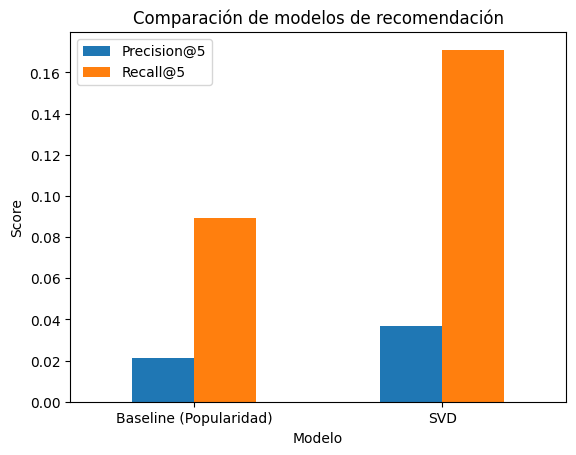

In [95]:
import matplotlib.pyplot as plt

comparacion.set_index("Modelo")[["Precision@5", "Recall@5"]].plot(kind="bar")

plt.title("Comparación de modelos de recomendación")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()